In [1]:
# import relevant libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import ast
import itertools

import warnings
warnings.filterwarnings("ignore")

In [2]:
# import the full df 

df = pd.read_csv('Presentation4_df.csv')

In [3]:
# import the call level data (used in the previous notebook)
call_df = pd.read_csv("call_level_df_new.csv").loc[:, lambda df: ~df.columns.str.contains("Unnamed")]
cols_to_convert = [
    "pre_queue_path_list",
    "full_path_list",
    "node_time_tuples",
    "pre_queue_node_time_tuples", 
    "unique_queues_visited"
]

# need to parse the columns with lists as values to be literal lists instead of strings 
for col in cols_to_convert:
    call_df[col] = call_df[col].apply(ast.literal_eval)

# If unique_queues_visited currently contains a list with one element, extract it
call_df["final_queue"] = call_df["unique_queues_visited"].apply(
    lambda x: x[0] if x else "No_queue_names"
)

# only filter calls that entered through the main number. 
call_df = call_df[call_df['EP Name'] == 'Main Number Telephony EP']

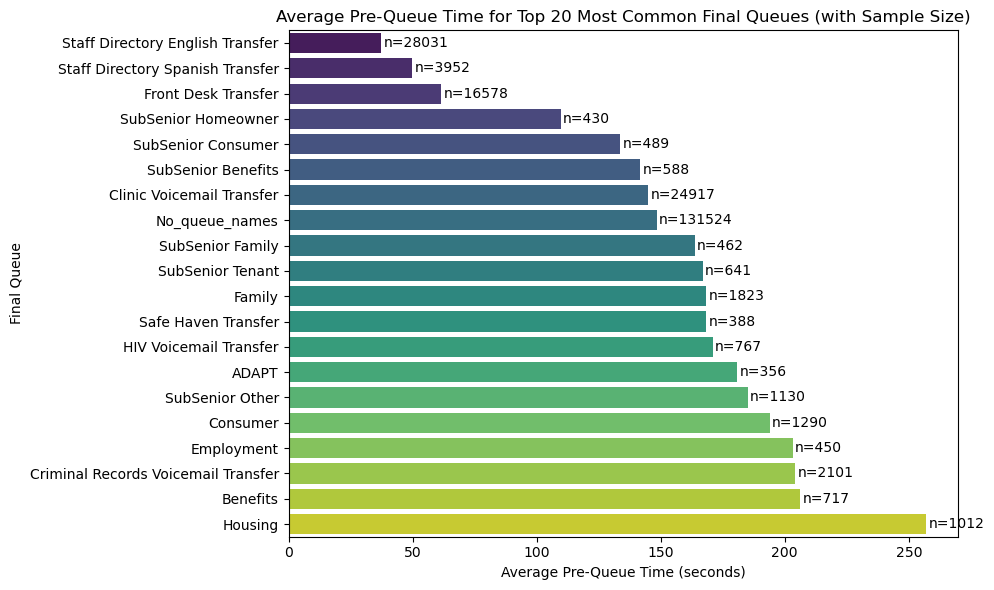

In [4]:

# Compute avg pre-queue time and sample size per final queue
queue_stats = (
    call_df.groupby("final_queue")
    .agg(
        avg_pre_queue_time_seconds=("pre_queue_total_time", "mean"),
        call_count=("Contact Session ID", "count")
    )
    .reset_index()
)

# Keep only top 20 most common final queues
top_queues = call_df["final_queue"].value_counts().head(20).index
queue_stats_top20 = queue_stats[queue_stats["final_queue"].isin(top_queues)]

# Sort by avg pre-queue time for horizontal bar plot
queue_stats_top20 = queue_stats_top20.sort_values("avg_pre_queue_time_seconds", ascending=True)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=queue_stats_top20,
    y="final_queue",
    x="avg_pre_queue_time_seconds",
    palette="viridis"
)

# Annotate bars with sample size
for i, row in enumerate(queue_stats_top20.itertuples()):
    ax.text(
        row.avg_pre_queue_time_seconds + 1,  # slightly right of bar
        i,  # use the positional index of the bar
        f'n={row.call_count}',
        va='center'
    )

plt.xlabel("Average Pre-Queue Time (seconds)")
plt.ylabel("Final Queue")
plt.title("Average Pre-Queue Time for Top 20 Most Common Final Queues (with Sample Size)")
plt.tight_layout()
plt.show()


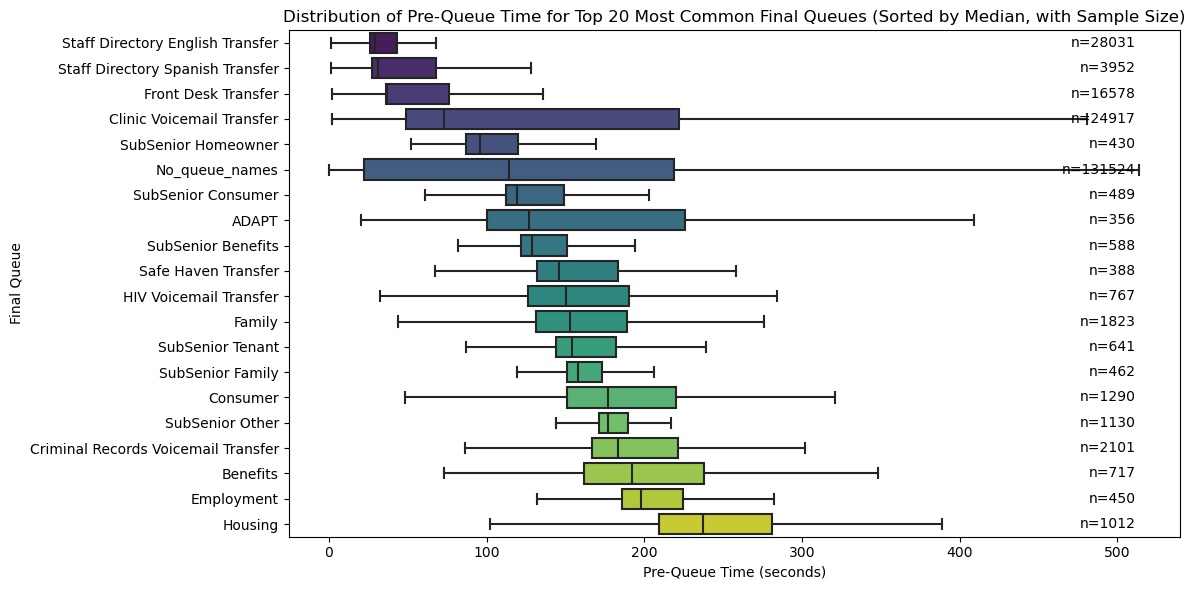

In [5]:
# Top 20 most common final queues
top_queues = call_df["final_queue"].value_counts().head(20).index
df_top20 = call_df[call_df["final_queue"].isin(top_queues)]

# Compute median pre-queue time per queue for sorting
median_times = df_top20.groupby("final_queue")["pre_queue_total_time"].median().sort_values()

# Set the order of queues by median
queue_order = median_times.index.tolist()

# Compute sample sizes
queue_counts = df_top20["final_queue"].value_counts()

plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=df_top20,
    y="final_queue",
    x="pre_queue_total_time",
    palette="viridis",
    showfliers=False,
    order=queue_order
)

# Annotate each box with sample size
for i, queue in enumerate(queue_order):
    n = queue_counts.get(queue, 0)
    ax.text(
        0.95,  # relative x-position
        i,     # y-position
        f'n={n}',
        va='center',
        ha='right',
        transform=ax.get_yaxis_transform()
    )

plt.xlabel("Pre-Queue Time (seconds)")
plt.ylabel("Final Queue")
plt.title("Distribution of Pre-Queue Time for Top 20 Most Common Final Queues (Sorted by Median, with Sample Size)")
plt.tight_layout()
plt.show()


In [6]:
# uncomment the below line to export the stats of the top 20 most common final queues. 

# queue_stats_top20.to_csv('queue_stats_top20.csv')

### Step 1: Get the shortest path for each final queue, 

We do this by finding the path to the final queue with the smallest number of nodes

In [7]:
# I want the shortest path for each final queue to give us an idea of what the optimal situation would be

df_top20 = df_top20.copy()
df_top20["path_len"] = df_top20["pre_queue_path_list"].apply(len)   # length of each path 

result = (
    df_top20.loc[
        df_top20.groupby("final_queue")["path_len"].idxmin(),
        ["final_queue", "pre_queue_path_list"]
    ]
)

# uncomment the below line to export the shortest paths for each final queue node to a csv/excel 
# result.to_csv("shortest_path_final_queue.csv")  

In [8]:
result

,final_queue,pre_queue_path_list
6314,ADAPT,"[LanguageSelectionMenu, MainMenu, SeniorsMenu,..."
79,Benefits,"[LanguageSelectionMenu, MainMenu, SeniorsMenu,..."
10,Clinic Voicemail Transfer,"[LanguageSelectionMenu, MainMenu, ClinicVoicem..."
60,Consumer,"[LanguageSelectionMenu, MainMenu, SeniorsMenu,..."
21,Criminal Records Voicemail Transfer,"[LanguageSelectionMenu, MainMenu, SeniorsMenu,..."
201,Employment,"[LanguageSelectionMenu, MainMenu, SeniorsMenu,..."
518,Family,"[LanguageSelectionMenu, MainMenu, SeniorsMenu,..."
11345,Front Desk Transfer,"[LanguageSelectionMenu, LanguageSelectionMenu]"
428,HIV Voicemail Transfer,"[LanguageSelectionMenu, MainMenu, SeniorsMenu,..."
228,Housing,"[LanguageSelectionMenu, MainMenu, SeniorsMenu,..."


### Step 2: find all unique nodes on involved in the shortest path, and the corresponding time for each node. 

In [9]:

# find the set of unique nodes that are involved in our paths 
unique_nodes = set(itertools.chain.from_iterable(result['pre_queue_path_list']))
print(unique_nodes)   # there are only 33! 

{'TransferToSafeHaven', 'LegalMenu1', 'FamilyMenu', 'MainMenu', 'GetLoggedInSubSeniorHomeownerAgents', 'SuburbsOrCityMenu', 'GetLoggedInBenefitsAgents', 'PreTenantMenu', 'GetLoggedInSubSeniorTenantAgents', 'GetLoggedInSubSeniorOtherAgents', 'EmploymentMenu', 'LanguageSelectionMenu', 'GetLoggedInSubSeniorBenefitsAgents', 'GetLoggedInSubSeniorFamilyAgents', 'GetLoggedInSubSeniorConsumerAgents', 'SuburbanSeniorsMenu', 'GetLoggedInConsumerAgents', 'GetLoggedInFamilyAgents', 'HousingMenu', 'HIVMenu', 'LegalMenu2', 'ClinicVoicemailTransfer', 'HIVVoicemailTransfer', 'BenefitsMenu', 'SeniorsConfirmationMenu', 'SeniorsMenu', 'GetLoggedInADAPTAgents', 'GetLoggedInHousingAgents', 'TenantMenu', 'GetLoggedInEmploymentAgents', 'StaffDirectorySpanishTransfer', 'StaffDirectoryEnglishTransfer', 'CriminalRecordsVoicemailTransfer'}


In [10]:
# Note: Since none of these have "SP" in them, these will be all in English (except for Staff Directory Spanish Transfer)

# there are 3 types of nodes in the shortest path 
    # Nodes that do not appear on the verbiage at all: these can be log-in nodes, which I assume takes no time (0 seconds)
    # Nodes that are on the verbiage list, but since there is no voice prompt, I do not know the actual length of the prompt
        # for these, these will become null when I join them 
    # Nodes that appear on the verbiage with a corresponding prompt (I can directly fill it in) 

# since there are some nodes that may appear as a node in the shortest path but there is no recording, I need to impute length of the prompt


# --------Prompt length imputation------------------
# I've manually added two columns to the verbiage: 
    # A column indicating the Node name corresponding to the prompt (so I can group with my data)
    # A column indicating the time length of the prompt. There are missing values in this. 

verbiage = pd.read_excel('Legal Aid Chicago Contact Center Prompt List Verbiage.xlsx') 
# number of words per prompt
verbiage['num_words_eng_prompt'] = verbiage['Updated Text'].apply(
    lambda x: len(str(x).split()) if pd.notnull(x) else 0
)

# filter rows with non-null time
valid = verbiage[verbiage["English Prompt Time (seconds)"].notnull()]
total_seconds = valid["English Prompt Time (seconds)"].sum()
total_words = valid["num_words_eng_prompt"].sum()

avg_seconds_per_word = total_seconds / total_words

# impute the length of the prompt based on this 
verbiage['English Prompt Time (seconds)'] = verbiage['English Prompt Time (seconds)'].fillna(
    verbiage['num_words_eng_prompt'] * avg_seconds_per_word
) 


In [11]:
# --------- merging the nodes present in the shortest path with their actual lengths ------------ 

# turn the set into a dataframe
nodes_df = pd.DataFrame({'Node Name': list(unique_nodes)})

# merge with verbiage to get the prompt time
nodes_with_time = nodes_df.merge(
    verbiage[['Node Name', 'English Prompt Time (seconds)']],
    on='Node Name',
    how='left'
)


In [12]:
## I want to verify the amount of time spent on each of the missing times nodes is actually 0. 

# 1. Nodes whose prompt time is missing
missing_nodes = set(
    nodes_with_time[nodes_with_time["English Prompt Time (seconds)"].isna()]["Node Name"]
)

# 2. Build a dictionary: node → list of observed times
node_time_dict = {node: [] for node in missing_nodes}

for row in df_top20["node_time_tuples"]:
    if isinstance(row, list):
        for node, t in row:
            if node in missing_nodes:
                # basically, append the times spent on nodes that are missing across the full data 
                node_time_dict[node].append(t) 
                
# 3. Convert into a dataframe of summary stats
summary_list = []

for node, times in node_time_dict.items():
    s = pd.Series(times)
    summary_list.append({
        "Node Name": node,
        "count": s.count(),
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(),
        "min": s.min(),
        "max": s.max()
    })

node_summary_stats = pd.DataFrame(summary_list)
node_summary_stats

# this indicates that the ideal amount of time spent on these nodes should be essentially 0. 
# for some reason, there are people who are spending a lot of time. We can note this. 

,Node Name,count,mean,median,std,min,max
0,TransferToSafeHaven,388,0.046392,0.0,0.210604,0.0,1.0
1,StaffDirectorySpanishTransfer,3953,0.057931,0.0,0.335083,0.0,11.0
2,GetLoggedInSubSeniorFamilyAgents,566,0.190813,0.0,0.397764,0.0,2.0
3,GetLoggedInSubSeniorBenefitsAgents,722,0.175900,0.0,0.380999,0.0,1.0
4,ClinicVoicemailTransfer,24920,0.443138,0.0,2.688247,0.0,34.0
5,HIVVoicemailTransfer,767,0.269883,0.0,1.993178,0.0,19.0
6,GetLoggedInSubSeniorConsumerAgents,611,0.183306,0.0,0.387234,0.0,1.0
7,GetLoggedInADAPTAgents,445,0.161798,0.0,0.368680,0.0,1.0
8,GetLoggedInHousingAgents,1200,0.163333,0.0,0.369824,0.0,1.0
9,GetLoggedInSubSeniorHomeownerAgents,530,0.160377,0.0,0.367302,0.0,1.0


In [13]:
# now we can safely impute this as 0
nodes_with_time['English Prompt Time (seconds)'] = nodes_with_time['English Prompt Time (seconds)'].fillna(0)

# nodes_with_time.to_excel('nodes_with_time.xlsx')

In [14]:
# make a dictionary for quick lookup
node_time_dict = nodes_with_time.set_index('Node Name')['English Prompt Time (seconds)'].to_dict()

# compute total time for each final queue
result['total_path_time'] = result['pre_queue_path_list'].apply(
    lambda path: sum(node_time_dict.get(node, 0) for node in path)
)


In [15]:
# full menu vs. early selection times computations 
    # I will refer to the result df, and find the time spent on each node in the "pre_queue_path_list" column and sum them up 

# early selection times: I assume each user selects once they've heard what they needed to get to where they want 
    # I assume language selection takes only 8 seconds, since very few need an interpreter 

# ALL OF THE FOLLOWING ARE DONE MANUALLY 
    # I listened and decided what is a easonable time to spend on each 

early_selection_times = {'ADAPT': 8 + 21 + 7.481435644 + 34 + 107,
'Benefits':8 + 21 + 7.481435644 + 34 + 58 + 11, 
'Clinic Voicemail Transfer': 8 + 29,
'Consumer': 8 + 21 + 7.481435644 + 34 + 74,
'Criminal Records Voicemail Transfer': 8 + 21 + 7.481435644 + 34 + 82,
'Employment': 8 + 21 + 7.481435644 + 34 + 88 + 5,
'Family': 8 + 21 + 7.481435644 + 34 + 30 + 7,
'Front Desk Transfer': 15.96039604 + 15.96039604, 
'HIV Voicemail Transfer': 8 + 21 + 7.481435644 + 34 + 6,
'Housing': 8 + 21 + 7.481435644 + 34 + 43 + 38 + 11,
'No_queue_names': 0,
'Safe Haven Transfer': 8 + 21 + 7.481435644 + 34 + 30 + 7,
'Staff Directory English Transfer': 8 + 29 + 13,
'Staff Directory Spanish Transfer': 8 + 29 + 13,
'SubSenior Benefits': 15.96039604 + 21 + 7.481435644 + 14.46410891 + 10 + 45,
'SubSenior Consumer': 15.96039604 + 21 + 7.481435644 + 14.46410891 + 10 + 35,
'SubSenior Family': 15.96039604 + 21 + 7.481435644 + 14.46410891 + 10 + 75, 
'SubSenior Homeowner': 15.96039604 + 21 + 7.481435644 + 14.46410891 + 10 + 13,
'SubSenior Other': 15.96039604 + 21 + 7.481435644 + 14.46410891 + 10 + 96,
'SubSenior Tenant': 15.96039604 + 21 + 7.481435644 + 14.46410891 + 10 + 26} 


# compute total time for each final queue
result['early_selection_total_time'] = result['final_queue'].map(early_selection_times)

## Final Combined Plot

In [16]:
final_df = pd.merge(queue_stats_top20, result, on='final_queue', how='left') 

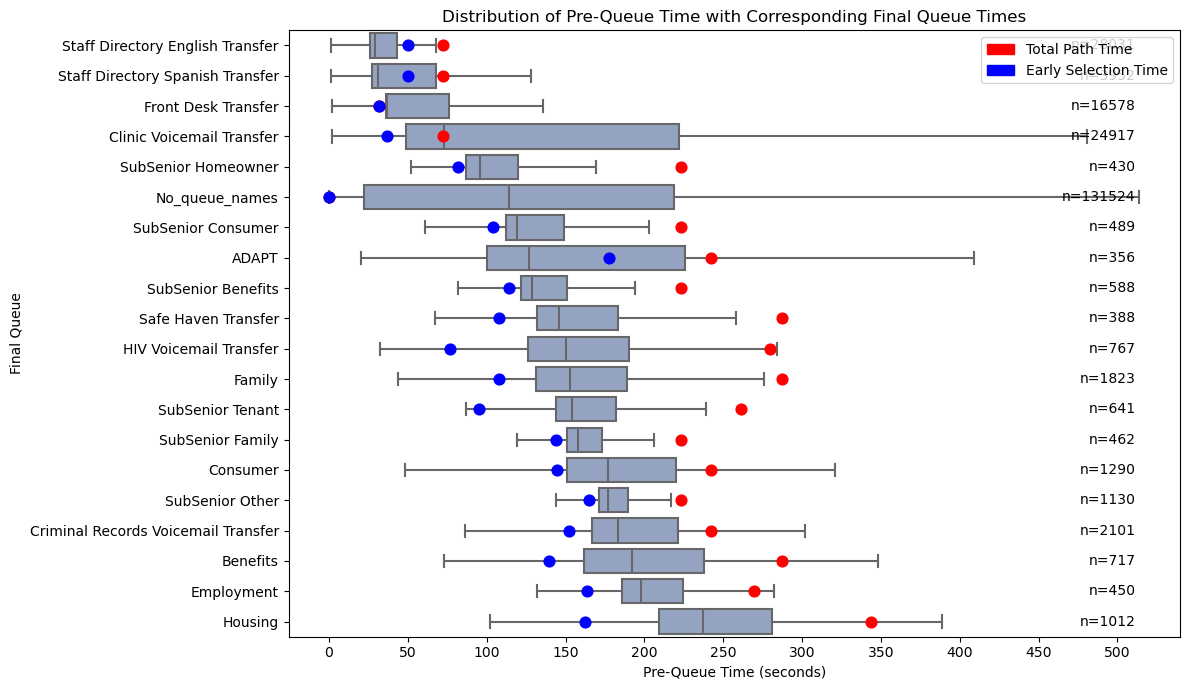

In [17]:
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator


plt.figure(figsize=(12, 7))

# Boxplot
ax = sns.boxplot(
    data=df_top20,
    y="final_queue",
    x="pre_queue_total_time",
    color="#8da0cb",
    showfliers=False,
    order=queue_order
)

# Annotate sample sizes
for i, queue in enumerate(queue_order):
    ax.text(0.95, i, f'n={queue_counts.get(queue,0)}', va='center', ha='right', transform=ax.get_yaxis_transform())

# Map queues to y positions
queue_to_y = {q: i for i, q in enumerate(queue_order)}

# Overlay points from final_df
for _, row in final_df.reset_index().iterrows():
    y = queue_to_y.get(row['final_queue'])
    if y is not None:
        ax.scatter(row['total_path_time'], y, color='red', s=60, zorder=10)
        ax.scatter(row['early_selection_total_time'], y, color='blue', s=60, zorder=10)

# Legend
ax.legend(handles=[Patch(color='red', label='Total Path Time'),
                   Patch(color='blue', label='Early Selection Time')])
# Set x-axis ticks every 50
ax.xaxis.set_major_locator(MultipleLocator(50))
plt.xlabel("Pre-Queue Time (seconds)")
plt.ylabel("Final Queue")
plt.title("Distribution of Pre-Queue Time with Corresponding Final Queue Times")
plt.tight_layout()
plt.show()

In [18]:
#Compute median pre-queue time per final_queue
median_length = df_top20.groupby("final_queue")["pre_queue_total_time"].median().reset_index()
median_length = median_length.rename(columns={"pre_queue_total_time": "median_length"})

# merge final_df to get early_selection_total_time
summary_df = pd.merge(median_length, final_df[["final_queue", "early_selection_total_time"]],
                      on="final_queue",
                      how="left")

# compute difference
summary_df["difference"] = summary_df["median_length"] - summary_df["early_selection_total_time"]

summary_df = summary_df.sort_values("difference", ascending=False).reset_index(drop=True)


In [19]:
summary_df

,final_queue,median_length,early_selection_total_time,difference
0,No_queue_names,114.0,0.000000,114.000000
1,Housing,237.0,162.481436,74.518564
2,HIV Voicemail Transfer,150.0,76.481436,73.518564
3,SubSenior Tenant,154.0,94.905941,59.094059
4,Benefits,192.0,139.481436,52.518564
5,Family,153.0,107.481436,45.518564
6,Safe Haven Transfer,146.0,107.481436,38.518564
7,Clinic Voicemail Transfer,73.0,37.000000,36.000000
8,Employment,198.0,163.481436,34.518564
9,Consumer,177.0,144.481436,32.518564


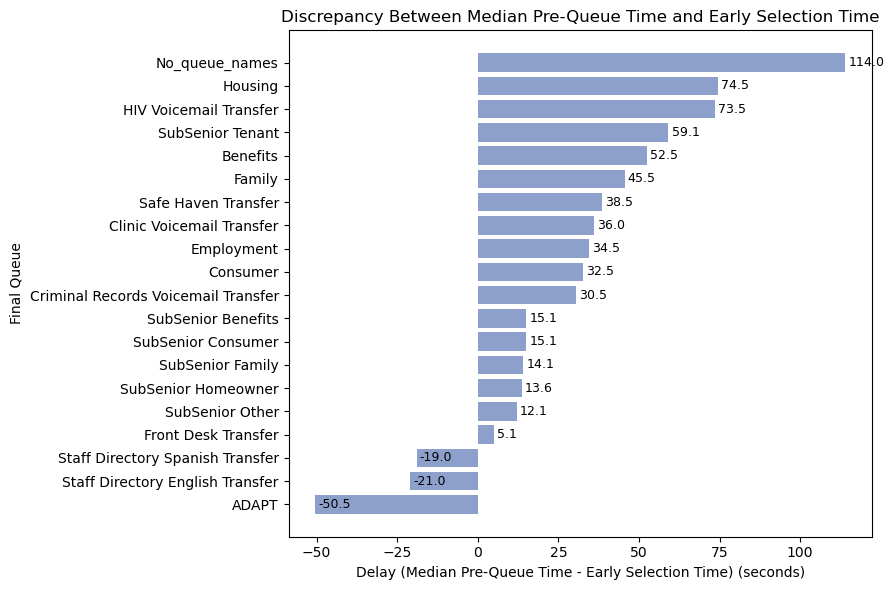

In [20]:
# Sort by difference for clarity
summary_df_sorted = summary_df.sort_values("difference", ascending=True)

plt.figure(figsize=(9, 6))
bars = plt.barh(summary_df_sorted["final_queue"], summary_df_sorted["difference"], color="#8da0cb")

# Add numerical labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             f"{width:.1f}", va='center', fontsize=9)

plt.xlabel("Delay (Median Pre-Queue Time - Early Selection Time) (seconds)")
plt.ylabel("Final Queue")
plt.title("Discrepancy Between Median Pre-Queue Time and Early Selection Time")
plt.tight_layout()
plt.show()

